In [ ]:
import os
import h5py
import requests
import matplotlib.pyplot as plt
import numpy as np
import time


In [8]:
key = "../api_key.txt"

with open(key) as file:
    api_key = file.read().strip()

In [9]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key": f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json()  # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename  # return the filename string

    return r

In [12]:
file2 = "illustris3_z0_positions.npz"
data2 = np.load("../data/simulations/illustris3/"+file2)
pos2 = np.column_stack([data2["x_pos"], data2["y_pos"], data2["z_pos"]])
print(f"loaded {len(pos2)} subhalos for {file2}")

loaded 121209 subhalos for illustris3_z0_positions.npz


In [13]:
np.random.seed(42)

n_data = 5000
idx = np.random.choice(len(pos2), size=min(n_data, len(pos2)), replace=False)
data_points = pos2[idx]

boxsize = 75000  # illustris-3 box = 75 Mpc/h = 75000 ckpc/h
n_random = 3 * len(data_points)
random_points = np.random.rand(n_random, 3) * boxsize

# need to have same dimensionality in y and z
bins = np.linspace(0.1, 1, 100) * boxsize
bin_centers = (bins)

def count_pairs(points1, points2, bins):
    pair_counts = np.zeros(len(bins) - 1)

    for i in range(len(points1)):
        distances_sq = np.sum((points1[i] - points2) ** 2, axis=1)
        counts, _ = np.histogram(np.sqrt(distances_sq), bins=bins)
        pair_counts += counts

    return pair_counts

dd = count_pairs(data_points, data_points, bins)
dr = count_pairs(data_points, random_points, bins)
rr = count_pairs(random_points, random_points, bins)


# get the num of points in each catalog
nD = len(data_points)
nR = len(random_points)

dd = dd / (nD * (nD - 1) / 2)
dr = dr / (nD * nR)
rr = rr / (nR * (nR - 1) / 2)

In [14]:
# COMPUTE THE 2PCF USING LANDY-SZALAY ESTIMATOR
# xi_unnormalized = (d - r)**2 = (d*d - d*r - r*d + r*r) = (dd - 2dr + rr)

xi = np.zeros_like(dd, dtype=float)
valid_bins = rr != 0
xi[valid_bins] = (dd[valid_bins] - 2 * dr[valid_bins] + rr[valid_bins]) / rr[valid_bins]
xi[~valid_bins] = np.nan  # assign NaN where rr = 0

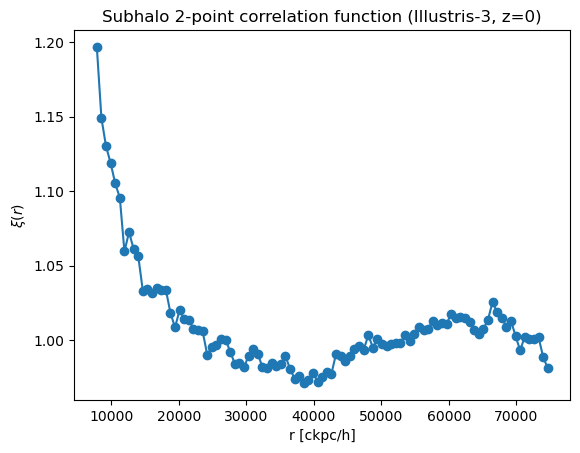

In [15]:
centers = 0.5 * (bins[:-1] + bins[1:])

plt.plot(centers, xi, "o-")
plt.xlabel("r [ckpc/h]")
plt.ylabel(r"$\xi(r)$")
plt.title("Subhalo 2-point correlation function (Illustris-3, z=0)")
plt.savefig("../figures/illustris3-1_2pcf.png", dpi=150, bbox_inches="tight")
plt.show()

# voids = 2pcf value of < min of 2pcf graph below(maybe 0.9) (0.5 for extreme, aka no objects near)

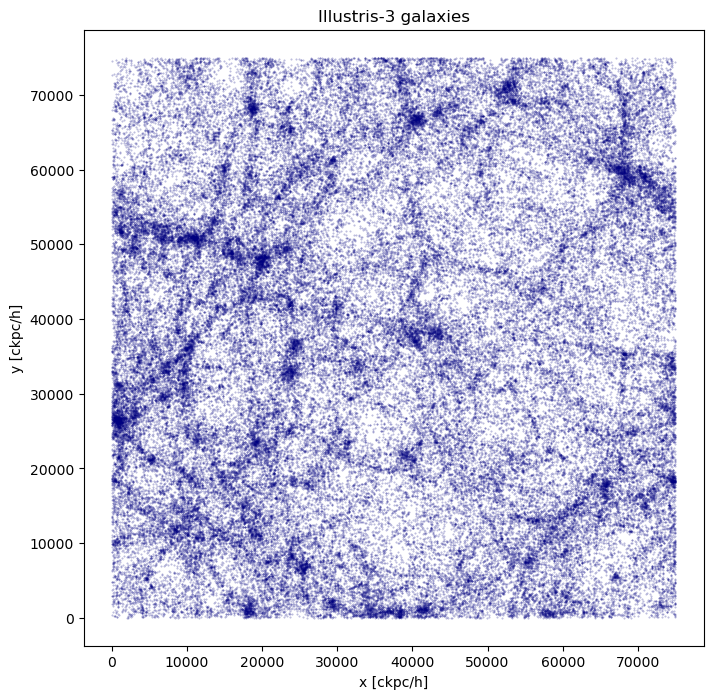

In [16]:
# plot them
fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(pos2[:, 0], pos2[:, 1], s=0.2, alpha=0.3, color="navy")
plt.xlabel("x [ckpc/h]")
plt.ylabel("y [ckpc/h]")
plt.title("Illustris-3 galaxies")
plt.savefig("../figures/illustris3-1_scatter_xy.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
ax.set_xlim(0, 75000)
ax.set_ylim(0, 75000)
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig("../figures/illustris3_clean_slice.png", dpi=150)